Iris Accuracy: 100.00%


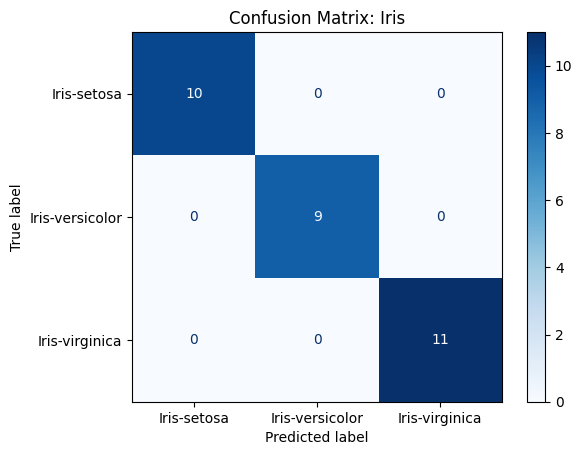

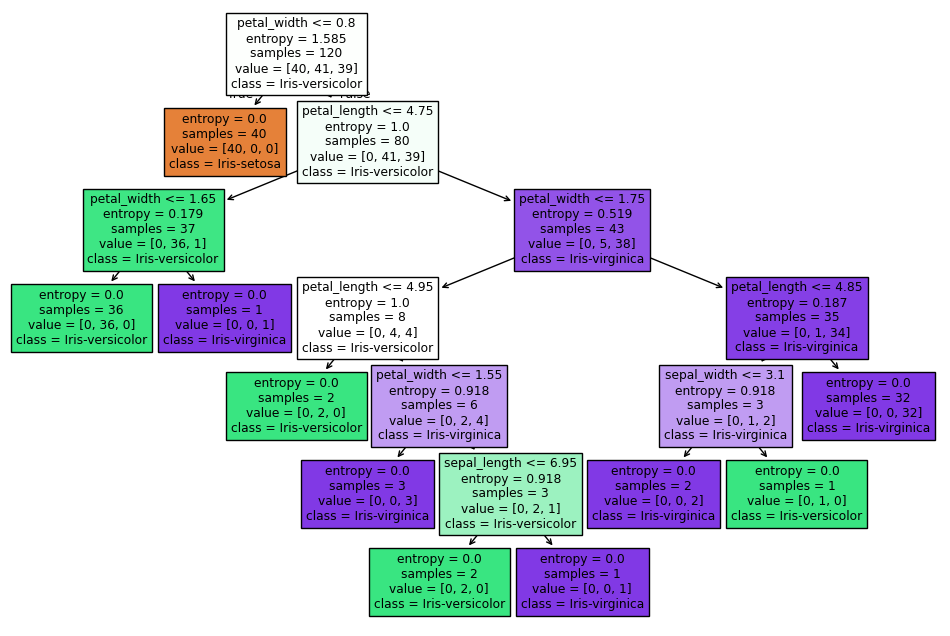

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load Iris dataset (using your uploaded file name)
iris = pd.read_csv('iris (1).csv')
X = iris.drop('species', axis=1)
y = iris['species']

# Split 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train using Entropy
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X_train, y_train)

# Predictions and Results
y_pred = clf.predict(X_test)
print(f"Iris Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Iris")
plt.show()

# Visualize the Tree
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=clf.classes_)
plt.show()

Drug Accuracy: 100.00%


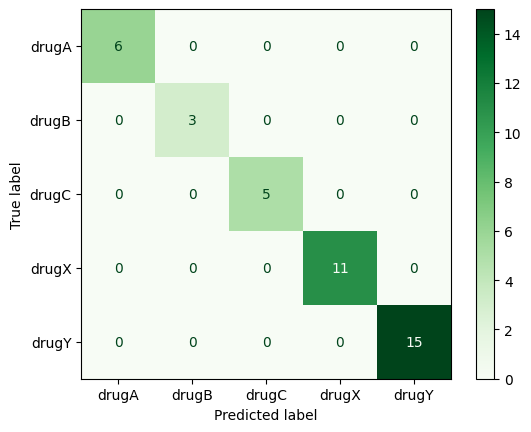

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

drug = pd.read_csv('drug.csv')

# Preprocessing: Encode categorical strings to numbers
le = LabelEncoder()
for col in ['Sex', 'BP', 'Cholesterol']:
    drug[col] = le.fit_transform(drug[col])

X = drug.drop('Drug', axis=1)
y = drug['Drug']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and Predict
clf_drug = DecisionTreeClassifier(criterion='entropy')
clf_drug.fit(X_train, y_train)
y_pred = clf_drug.predict(X_test)

print(f"Drug Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_drug.classes_)
disp.plot(cmap='Greens')
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

petrol = pd.read_csv('petrol_consumption.csv')
X = petrol.drop('Petrol_Consumption', axis=1)
y = petrol['Petrol_Consumption']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use DecisionTreeRegressor (for continuous values)
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

# Evaluate with Error Metrics
y_pred = regressor.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("--- Petrol Consumption Error Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

--- Petrol Consumption Error Metrics ---
Mean Absolute Error (MAE): 94.70
Mean Squared Error (MSE): 17511.70
Root Mean Squared Error (RMSE): 132.33


In [6]:
import pandas as pd
import numpy as np

# Data from Lab slide
data = {
    'a2': ['Hot', 'Hot', 'Hot', 'Cool', 'Cool', 'Cool', 'Hot', 'Hot', 'Cool', 'Cool'],
    'a3': ['High', 'High', 'High', 'Normal', 'Normal', 'High', 'High', 'Normal', 'Normal', 'High'],
    'Classification': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes']
}
df = pd.DataFrame(data)

def entropy(target_col):
    counts = target_col.value_counts(normalize=True)
    return -np.sum(counts * np.log2(counts))

def info_gain(df, attr, target):
    total_ent = entropy(df[target])
    weighted_ent = df.groupby(attr)[target].apply(lambda x: (len(x)/len(df)) * entropy(x)).sum()
    return total_ent - weighted_ent

ig_a2 = info_gain(df, 'a2', 'Classification')
ig_a3 = info_gain(df, 'a3', 'Classification')

print(f"Total Entropy: {entropy(df['Classification']):.4f}")
print(f"Information Gain for a2: {ig_a2:.4f}")
print(f"Information Gain for a3: {ig_a3:.4f}")
print(f"Decision: Splitting node should be {'a2' if ig_a2 > ig_a3 else 'a3'}")

Total Entropy: 0.9710
Information Gain for a2: 0.1245
Information Gain for a3: 0.4200
Decision: Splitting node should be a3
